# Presença Operacional de Shipping Lines no Brasil — 2025
**Análise:** Escalas, KPIs operacionais, deployment e frota activa por carrier  
**Fontes:** ANTAQ 2025_Atracacao · 2025_Tempos_Atracacao · Vessels_Master_Enriched  
**Escopo:** Longo Curso + Cabotagem | Container shipping lines identificadas

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE = Path('../data')
OPS  = BASE / '02_Operacoes'
IND  = BASE / '03_Indicadores'
OUT  = Path('../outputs/figures')
PROC = Path('../outputs/processed_data')
OUT.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

CARRIER_COLORS = {
    'MAERSK'     : '#0043A8',
    'MSC'        : '#D4002A',
    'CMA CGM'    : '#E8821A',
    'COSCO'      : '#EE2020',
    'EVERGREEN'  : '#2D8C2D',
    'Hapag-Lloyd': '#FF6600',
    'ONE'        : '#E60073',
    'ZIM'        : '#00539B',
    'Outros/N.I.': '#AAAAAA',
}
MES_ORDER = ['jan','fev','mar','abr','mai','jun','jul','ago','set','out','nov','dez']
SEG_ORDER = [
    'Feeder Max (1k-3k TEU)',
    'Sub-Panamax (3k-8k TEU)',
    'Post-Panamax (8k-12k TEU)',
    'New Panamax (12k-18k TEU)',
    'Ultra Large (> 18k TEU)',
]

## 1. Pré-processamento

### Passo 1 — Filtrar Atracação: Longo Curso + Cabotagem

In [2]:
atr_raw = pd.read_csv(OPS / '2025_Atracacao.csv', sep=';', encoding='utf-8-sig', low_memory=False)

# Limpar IMO (zeros = nulos efectivos)
def clean_imo(x):
    if pd.isna(x): return None
    s = str(x).strip().replace('.0', '')
    return None if s in ['0', ''] else s

atr_raw['IMO_clean'] = atr_raw['Nº do IMO'].apply(clean_imo)

LC_CAB = ['Longo Curso', 'Cabotagem']
df = atr_raw[atr_raw['Tipo de Navegação da Atracação'].isin(LC_CAB)].copy()

print(f'Total atracações 2025            : {len(atr_raw):,}')
print(f'Após filtro LC + Cabotagem       : {len(df):,}')
print(f'  → Longo Curso                  : {(df["Tipo de Navegação da Atracação"]=="Longo Curso").sum():,}')
print(f'  → Cabotagem                    : {(df["Tipo de Navegação da Atracação"]=="Cabotagem").sum():,}')

Total atracações 2025            : 116,098
Após filtro LC + Cabotagem       : 43,929
  → Longo Curso                  : 22,746
  → Cabotagem                    : 21,183


### Passo 2 — Join com Vessels_Master_Enriched (carrier identification)

In [3]:
v = pd.read_csv(OPS / 'Vessels_Master_Enriched.csv', low_memory=False)
v['IMO_str'] = v['NÚMERO IMO'].astype(str)

df = df.merge(
    v[['IMO_str', 'SHIPPING LINE', 'vessel_segment', 'CAPACIDADE (TEU)', 'dwt', 'loa', 'year_built']],
    left_on='IMO_clean', right_on='IMO_str', how='left'
)

df['container_identified'] = df['SHIPPING LINE'].notna()
df['carrier_label'] = df['SHIPPING LINE'].fillna('Outros/N.I.')

n_id  = df['container_identified'].sum()
n_tot = len(df)
print(f'Carriers identificados (Vessels_Master): {len(v["SHIPPING LINE"].unique())}')
print(f'Atracações com carrier identificado     : {n_id:,} ({n_id/n_tot*100:.1f}%)')
print(f'Atracações Outros/N.I.                  : {n_tot-n_id:,} ({(n_tot-n_id)/n_tot*100:.1f}%)')
print()
print('Nota: Vessels_Master cobre exclusivamente container shipping.')
print('Atracações não identificadas incluem tankers, bulk carriers, RoRo, etc.')

Carriers identificados (Vessels_Master): 8
Atracações com carrier identificado     : 958 (2.2%)
Atracações Outros/N.I.                  : 42,971 (97.8%)

Nota: Vessels_Master cobre exclusivamente container shipping.
Atracações não identificadas incluem tankers, bulk carriers, RoRo, etc.


### Passo 3 — Join com Tempos de Atracação

In [4]:
t = pd.read_csv(IND / '2025_Tempos_Atracacao.csv', sep=';', encoding='utf-8-sig')

TCOLS = ['TEsperaAtracacao', 'TEsperaInicioOp', 'TOperacao',
         'TEsperaDesatracacao', 'TAtracado', 'TEstadia']
for c in TCOLS:
    t[c] = pd.to_numeric(t[c].astype(str).str.replace(',', '.', regex=False), errors='coerce')

df = df.merge(t[['IDAtracacao'] + TCOLS], on='IDAtracacao', how='left')

carriers = df[df['container_identified']].copy()
print(f'Dataset final (container identified + tempos): {len(carriers):,} atracações')
print(f'Cobertura de TEstadia: {carriers["TEstadia"].notna().mean()*100:.1f}%')

Dataset final (container identified + tempos): 958 atracações
Cobertura de TEstadia: 98.7%


## 2. Análise Parte 1 — Presença Operacional Real

### 2.1 Escalas por Carrier (LC vs Cabotagem, portos, navios)

In [5]:
# Frota registada (denominador)
frota_reg = v.groupby('SHIPPING LINE').size().rename('Frota_Registada')

tabela_escalas = carriers.groupby('SHIPPING LINE').agg(
    Total_Escalas        = ('IDAtracacao',  'count'),
    Longo_Curso          = ('Tipo de Navegação da Atracação', lambda x: (x == 'Longo Curso').sum()),
    Cabotagem            = ('Tipo de Navegação da Atracação', lambda x: (x == 'Cabotagem').sum()),
    Portos_Unicos        = ('Porto Atracação', 'nunique'),
    Navios_Unicos        = ('IMO_clean',       'nunique'),
).sort_values('Total_Escalas', ascending=False)

tabela_escalas = tabela_escalas.join(frota_reg)
tabela_escalas['Frota_Activa_%'] = (
    tabela_escalas['Navios_Unicos'] / tabela_escalas['Frota_Registada'] * 100
).round(1)
tabela_escalas['Escalas_por_Navio'] = (
    tabela_escalas['Total_Escalas'] / tabela_escalas['Navios_Unicos']
).round(1)
tabela_escalas['Share_LC_%'] = (
    tabela_escalas['Longo_Curso'] / tabela_escalas['Total_Escalas'] * 100
).round(1)

print('=== Escalas por Carrier — 2025 (Longo Curso + Cabotagem) ===')
print(tabela_escalas.to_string())

=== Escalas por Carrier — 2025 (Longo Curso + Cabotagem) ===
               Total_Escalas  Longo_Curso  Cabotagem  Portos_Unicos  Navios_Unicos  Frota_Registada  Frota_Activa_%  Escalas_por_Navio  Share_LC_%
SHIPPING LINE                                                                                                                                     
MAERSK                   311          191        120             28             21              261             8.0               14.8        61.4
MSC                      169          157         12             20             19              220             8.6                8.9        92.9
COSCO                    156          100         56             39             25              335             7.5                6.2        64.1
Hapag-Lloyd              121           66         55             23              6              100             6.0               20.2        54.5
EVERGREEN                100          100          0     

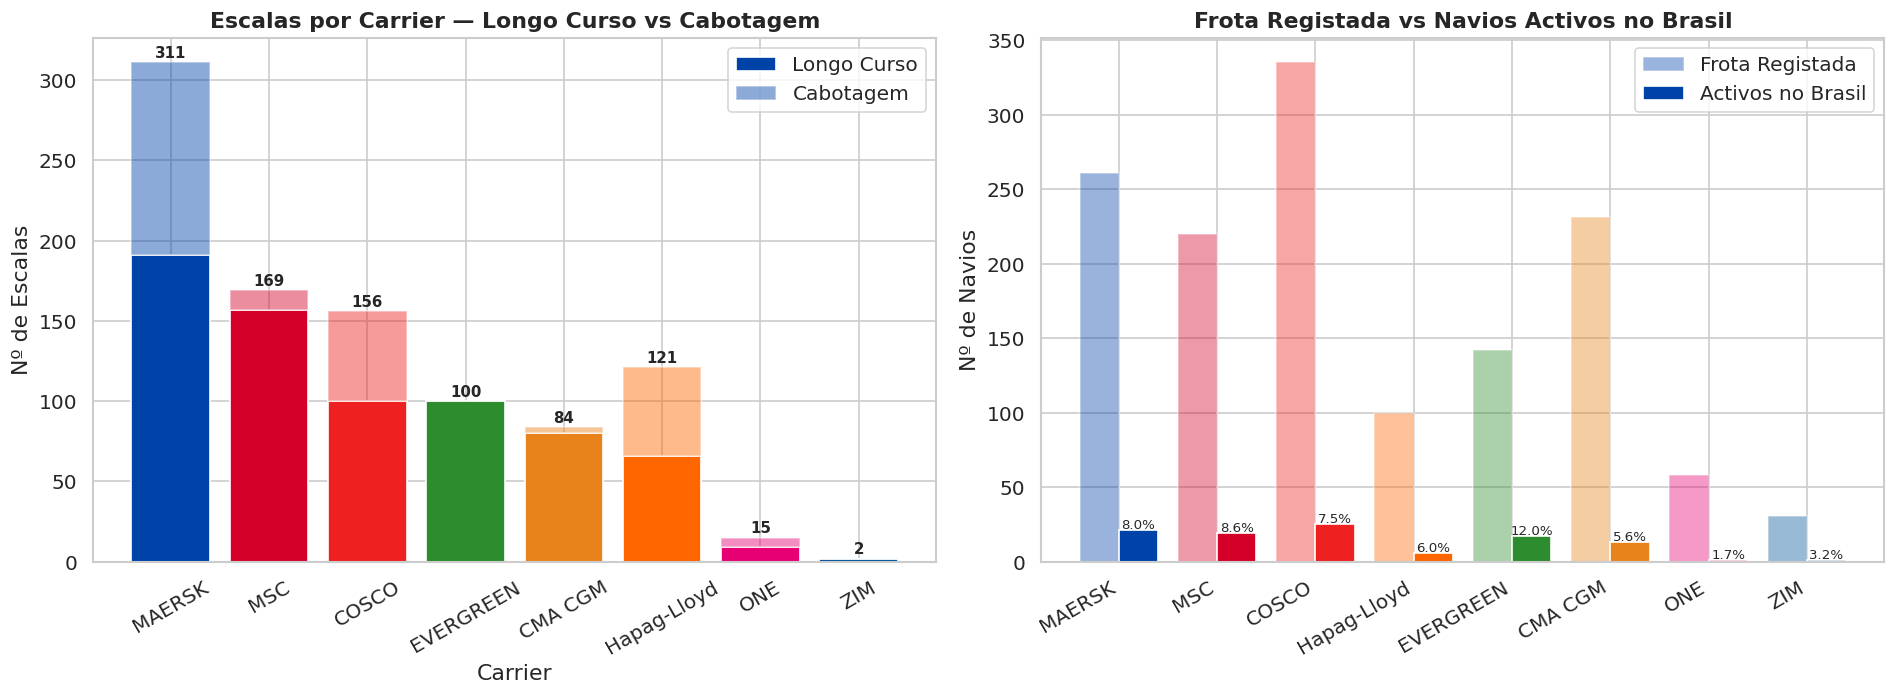

In [6]:
# Visualização: Escalas LC vs Cabotagem por carrier
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar: LC vs Cab
plot_data = tabela_escalas[['Longo_Curso', 'Cabotagem']].sort_values('Longo_Curso', ascending=False)
bar_colors_lc  = [CARRIER_COLORS.get(c, '#888') for c in plot_data.index]

bottom = np.zeros(len(plot_data))
for col, alpha in [('Longo_Curso', 1.0), ('Cabotagem', 0.45)]:
    vals = plot_data[col].values
    bars = axes[0].bar(plot_data.index, vals, bottom=bottom,
                       color=bar_colors_lc, alpha=alpha,
                       edgecolor='white', label=col.replace('_',' '))
    bottom += vals

axes[0].set_title('Escalas por Carrier — Longo Curso vs Cabotagem', fontweight='bold')
axes[0].set_xlabel('Carrier')
axes[0].set_ylabel('Nº de Escalas')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)
for i, (carrier, row) in enumerate(plot_data.iterrows()):
    total = row['Longo_Curso'] + row['Cabotagem']
    axes[0].text(i, total + 3, str(total), ha='center', fontsize=9, fontweight='bold')

# Navios únicos vs frota registada
x = np.arange(len(tabela_escalas))
w = 0.4
axes[1].bar(x - w/2, tabela_escalas['Frota_Registada'], width=w, label='Frota Registada',
            color=[CARRIER_COLORS.get(c, '#888') for c in tabela_escalas.index], alpha=0.4)
axes[1].bar(x + w/2, tabela_escalas['Navios_Unicos'], width=w, label='Activos no Brasil',
            color=[CARRIER_COLORS.get(c, '#888') for c in tabela_escalas.index], alpha=1.0)
axes[1].set_xticks(x)
axes[1].set_xticklabels(tabela_escalas.index, rotation=30, ha='right')
axes[1].set_title('Frota Registada vs Navios Activos no Brasil', fontweight='bold')
axes[1].set_ylabel('Nº de Navios')
axes[1].legend()
for xi, (_, row) in zip(x, tabela_escalas.iterrows()):
    axes[1].text(xi + w/2, row['Navios_Unicos'] + 1,
                 f"{row['Frota_Activa_%']}%", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUT / 'nb10_01_escalas_frota.png', bbox_inches='tight')
plt.show()

### 2.2 Top 5 Portos por Carrier

In [7]:
print('Top 5 Portos por Carrier (nº escalas):')
print('=' * 60)
for carrier in tabela_escalas.index:
    top5 = (
        carriers[carriers['SHIPPING LINE'] == carrier]['Porto Atracação']
        .value_counts()
        .head(5)
    )
    total = tabela_escalas.loc[carrier, 'Total_Escalas']
    top5_pct = (top5 / total * 100).round(1)
    concentracao = top5.sum() / total * 100
    print(f'\n{carrier} ({total} escalas | Top-5 = {concentracao:.0f}% do total):')
    for porto, n in top5.items():
        print(f'  {porto:<50} {n:>3} ({top5_pct[porto]:.1f}%)')

Top 5 Portos por Carrier (nº escalas):

MAERSK (311 escalas | Top-5 = 53% do total):
  Santos                                              51 (16.4%)
  Porto Itapoá Terminais Portuários                   37 (11.9%)
  Paranaguá                                           27 (8.7%)
  Terminal Portuário do Pecém                         26 (8.4%)
  Itajaí                                              23 (7.4%)

MSC (169 escalas | Top-5 = 64% do total):
  Santos                                              39 (23.1%)
  Rio de Janeiro                                      30 (17.8%)
  Suape                                               14 (8.3%)
  Paranaguá                                           14 (8.3%)
  Terminal Portuário do Pecém                         11 (6.5%)

COSCO (156 escalas | Top-5 = 46% do total):
  Santos                                              21 (13.5%)
  Suape                                               16 (10.3%)
  Vila do Conde                                      

### 2.3 Distribuição por Vessel Segment

Distribuição de Escalas por Vessel Segment (nº absoluto):
vessel_segment  Feeder Max (1k-3k TEU)  Sub-Panamax (3k-8k TEU)  Post-Panamax (8k-12k TEU)  New Panamax (12k-18k TEU)  Ultra Large (> 18k TEU)
SHIPPING LINE                                                                                                                                 
CMA CGM                             67                        8                          6                          3                        0
COSCO                                0                      137                         11                          8                        0
EVERGREEN                           15                        0                         20                         60                        5
Hapag-Lloyd                          0                       47                         73                          0                        1
MAERSK                              16                      142                     

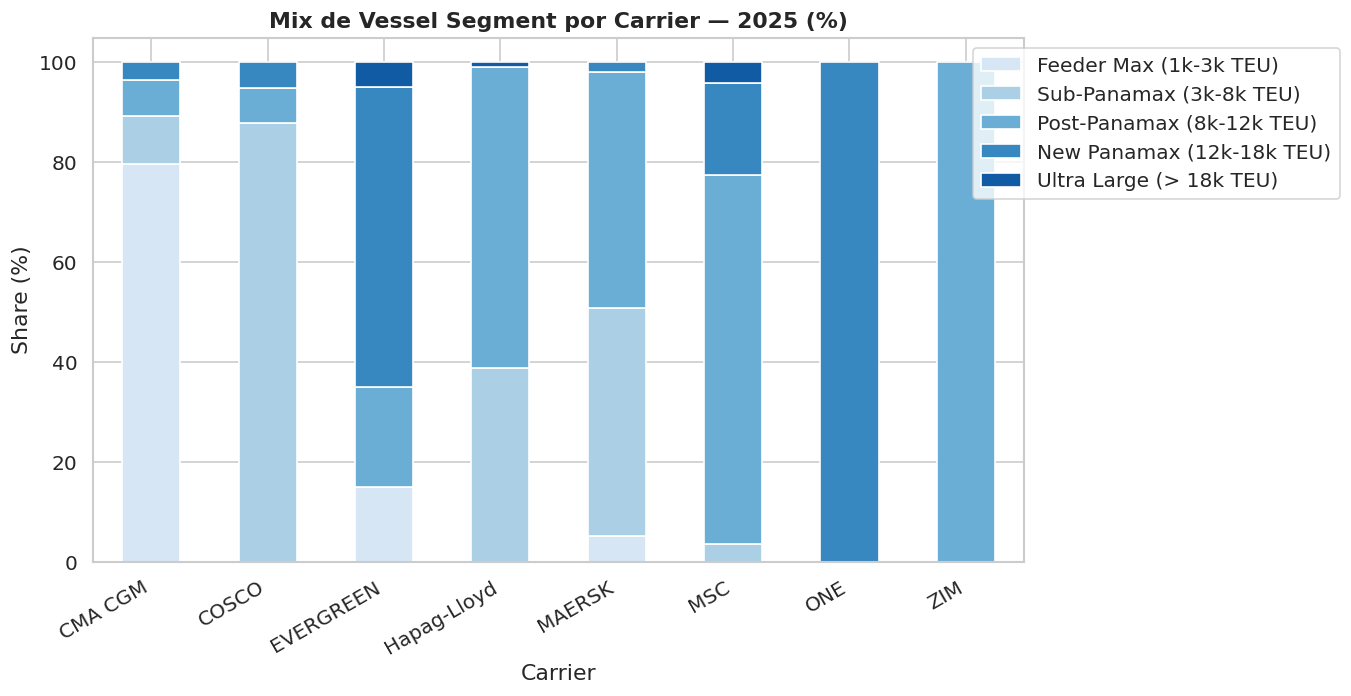

In [8]:
seg_dist = (
    carriers.groupby(['SHIPPING LINE', 'vessel_segment'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SEG_ORDER, fill_value=0)
)
seg_pct = seg_dist.div(seg_dist.sum(axis=1), axis=0) * 100

print('Distribuição de Escalas por Vessel Segment (nº absoluto):')
print(seg_dist.to_string())
print('\nDistribuição (%):')
print(seg_pct.round(1).to_string())

# Stacked bar
seg_colors = sns.color_palette('Blues', len(SEG_ORDER))
seg_pct.plot.bar(stacked=True, figsize=(12, 6), color=seg_colors, edgecolor='white')
plt.title('Mix de Vessel Segment por Carrier — 2025 (%)', fontweight='bold')
plt.xlabel('Carrier')
plt.ylabel('Share (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.tight_layout()
plt.savefig(OUT / 'nb10_02_segment_mix.png', bbox_inches='tight')
plt.show()

### 2.4 Evolução Mensal de Escalas

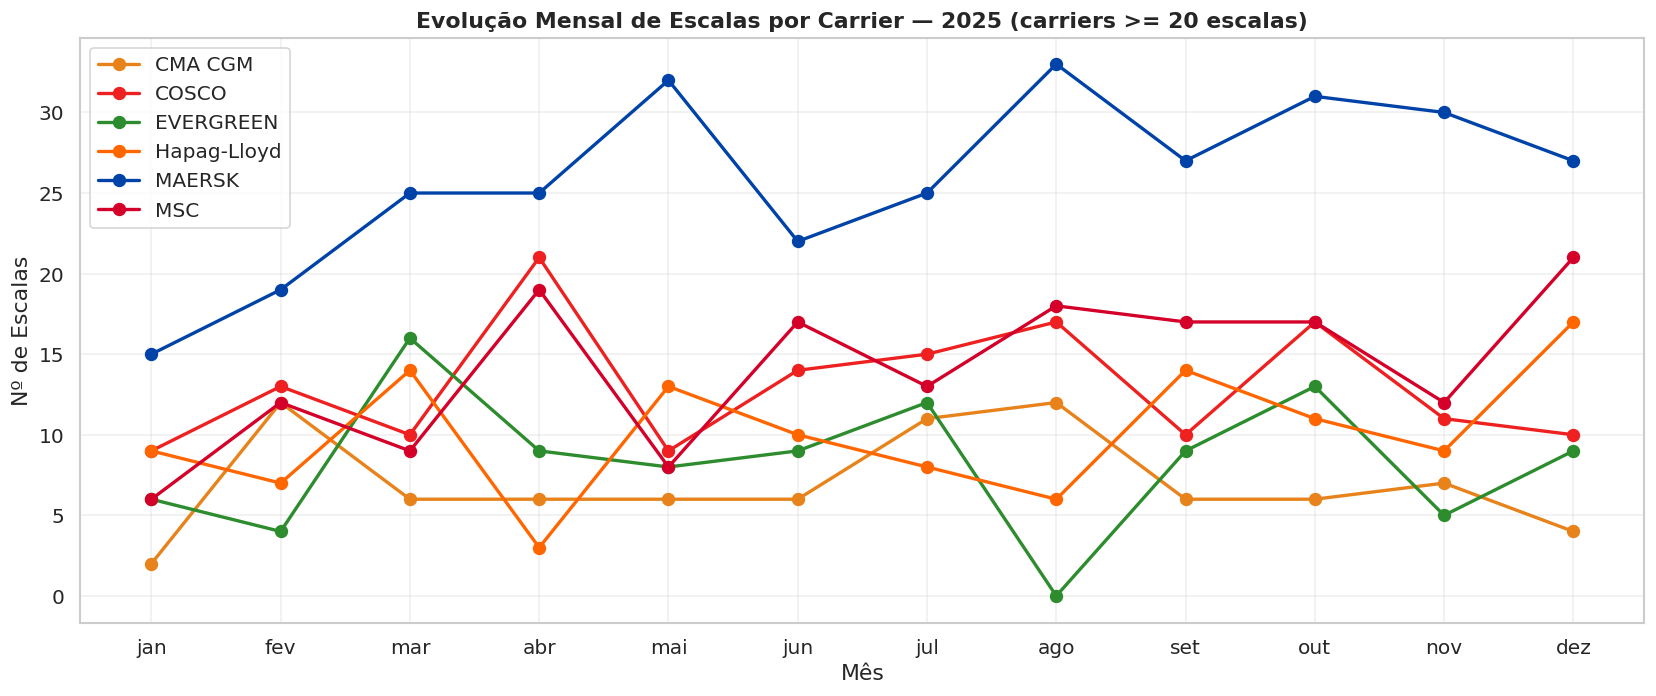

Escalas mensais (todos os carriers):
Mes            jan  fev  mar  abr  mai  jun  jul  ago  set  out  nov  dez
SHIPPING LINE                                                            
CMA CGM          2   12    6    6    6    6   11   12    6    6    7    4
COSCO            9   13   10   21    9   14   15   17   10   17   11   10
EVERGREEN        6    4   16    9    8    9   12    0    9   13    5    9
Hapag-Lloyd      9    7   14    3   13   10    8    6   14   11    9   17
MAERSK          15   19   25   25   32   22   25   33   27   31   30   27
MSC              6   12    9   19    8   17   13   18   17   17   12   21
ONE              3    0    6    0    0    0    0    0    0    0    0    6
ZIM              0    0    0    0    1    0    0    0    0    0    1    0


In [9]:
mensal = (
    carriers.groupby(['SHIPPING LINE', 'Mes'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=MES_ORDER)
)

# Excluir ONE e ZIM (< 20 escalas) da visualização principal
mensal_main = mensal[mensal.sum(axis=1) >= 20]

fig, ax = plt.subplots(figsize=(14, 6))
for carrier in mensal_main.index:
    color = CARRIER_COLORS.get(carrier, '#888')
    ax.plot(MES_ORDER, mensal_main.loc[carrier], marker='o',
            color=color, linewidth=2, markersize=7, label=carrier)

ax.set_title('Evolução Mensal de Escalas por Carrier — 2025 (carriers >= 20 escalas)', fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Nº de Escalas')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'nb10_03_escalas_mensal.png', bbox_inches='tight')
plt.show()

print('Escalas mensais (todos os carriers):')
print(mensal.to_string())

## 3. Análise Parte 2 — KPIs Operacionais por Carrier

### 3.1 Medianas de Tempo por Carrier vs Benchmark de Mercado

In [10]:
# Carriers com >= 20 escalas
carriers_20 = carriers[
    carriers['SHIPPING LINE'].isin(
        carriers.groupby('SHIPPING LINE').size()[lambda x: x >= 20].index
    )
].copy()

# Benchmark: mediana geral LC+Cab (todos os tipos de navio)
benchmark = df[TCOLS].median()

kpi_carrier = (
    carriers_20.groupby('SHIPPING LINE')[TCOLS]
    .median()
    .round(2)
    .sort_values('TEstadia')
)

print('KPIs Operacionais por Carrier — Mediana (horas):')
print(kpi_carrier.to_string())
print('\nBenchmark geral LC+Cab (mediana):')
print(benchmark.round(2).to_string())

print('\nDesvio vs benchmark (carrier mediana - benchmark):')
desvio = kpi_carrier - benchmark
print(desvio.round(2).to_string())

KPIs Operacionais por Carrier — Mediana (horas):
               TEsperaAtracacao  TEsperaInicioOp  TOperacao  TEsperaDesatracacao  TAtracado  TEstadia
SHIPPING LINE                                                                                        
MAERSK                     4.80             1.63      17.63                 2.02      22.09     30.98
Hapag-Lloyd                9.46             1.90      16.76                 3.05      22.55     39.36
MSC                       11.45             1.88      19.70                 2.22      23.86     43.08
EVERGREEN                 19.60             1.25      19.83                 1.75      24.47     50.75
COSCO                     16.19             3.17      26.50                 3.64      34.90     64.40
CMA CGM                    4.37             2.32      40.13                 3.21      51.42     73.65

Benchmark geral LC+Cab (mediana):
TEsperaAtracacao        3.33
TEsperaInicioOp         1.40
TOperacao              19.90
TEsperaDesatr

### 3.2 Bar Chart: TEstadia Mediana por Carrier + Benchmark

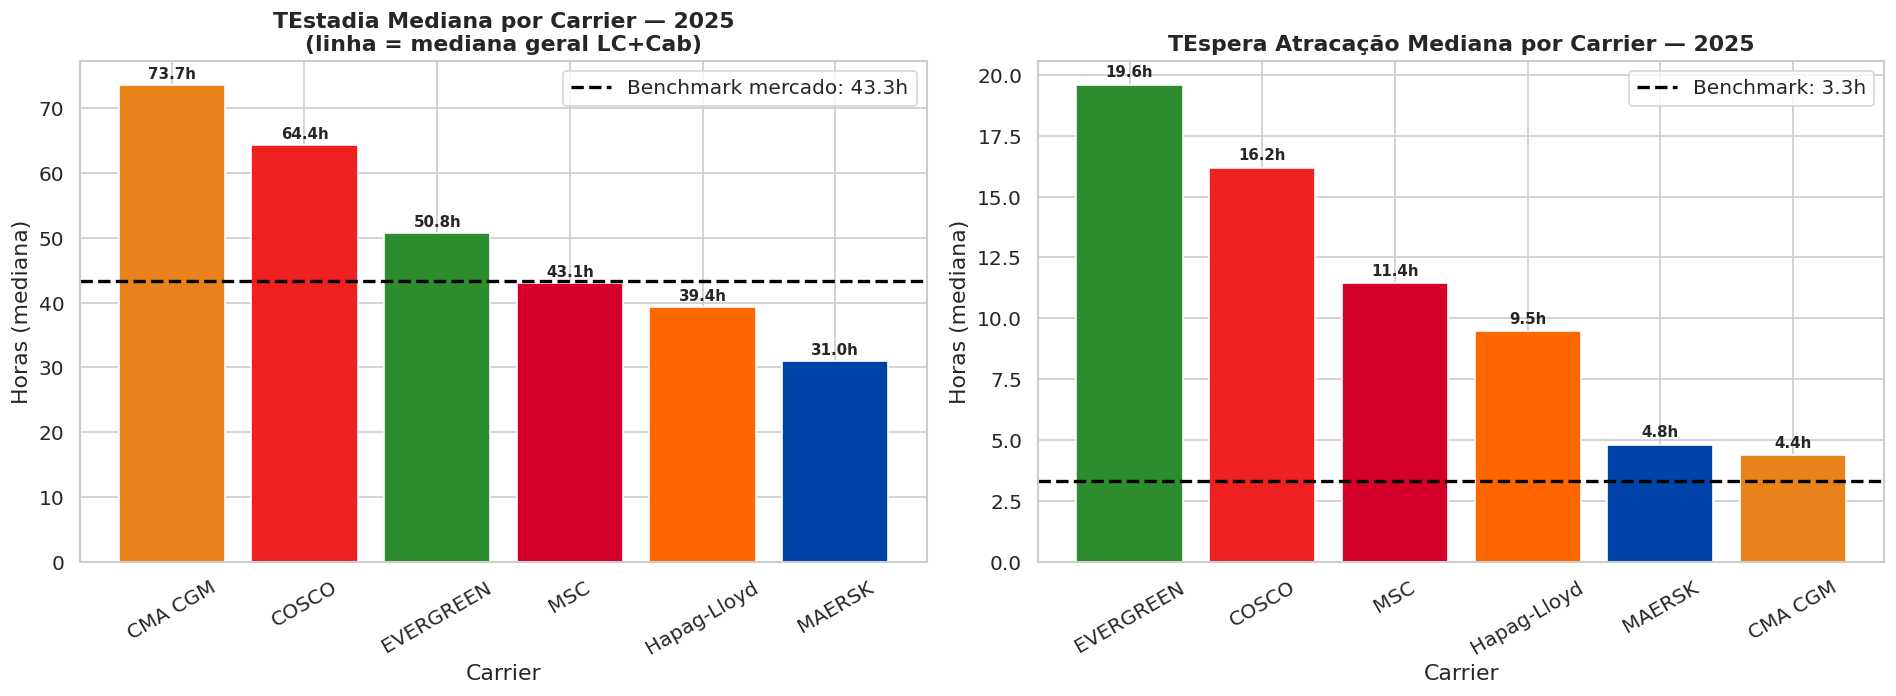

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TEstadia
estadia_sorted = kpi_carrier['TEstadia'].sort_values(ascending=False)
colors_bar = [CARRIER_COLORS.get(c, '#888') for c in estadia_sorted.index]
bars = axes[0].bar(estadia_sorted.index, estadia_sorted.values, color=colors_bar, edgecolor='white')
axes[0].axhline(benchmark['TEstadia'], color='black', linestyle='--', linewidth=2,
                label=f'Benchmark mercado: {benchmark["TEstadia"]:.1f}h')
axes[0].set_title('TEstadia Mediana por Carrier — 2025\n(linha = mediana geral LC+Cab)', fontweight='bold')
axes[0].set_xlabel('Carrier')
axes[0].set_ylabel('Horas (mediana)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)
for bar, vval in zip(bars, estadia_sorted.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, vval + 0.5,
                 f'{vval:.1f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')

# TEsperaAtracacao
espera_sorted = kpi_carrier['TEsperaAtracacao'].sort_values(ascending=False)
colors_bar2 = [CARRIER_COLORS.get(c, '#888') for c in espera_sorted.index]
bars2 = axes[1].bar(espera_sorted.index, espera_sorted.values, color=colors_bar2, edgecolor='white')
axes[1].axhline(benchmark['TEsperaAtracacao'], color='black', linestyle='--', linewidth=2,
                label=f'Benchmark: {benchmark["TEsperaAtracacao"]:.1f}h')
axes[1].set_title('TEspera Atracação Mediana por Carrier — 2025', fontweight='bold')
axes[1].set_xlabel('Carrier')
axes[1].set_ylabel('Horas (mediana)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)
for bar, vval in zip(bars2, espera_sorted.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, vval + 0.2,
                 f'{vval:.1f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT / 'nb10_04_kpis_tempo_carrier.png', bbox_inches='tight')
plt.show()

### 3.3 Radar / Ranking Completo de KPIs

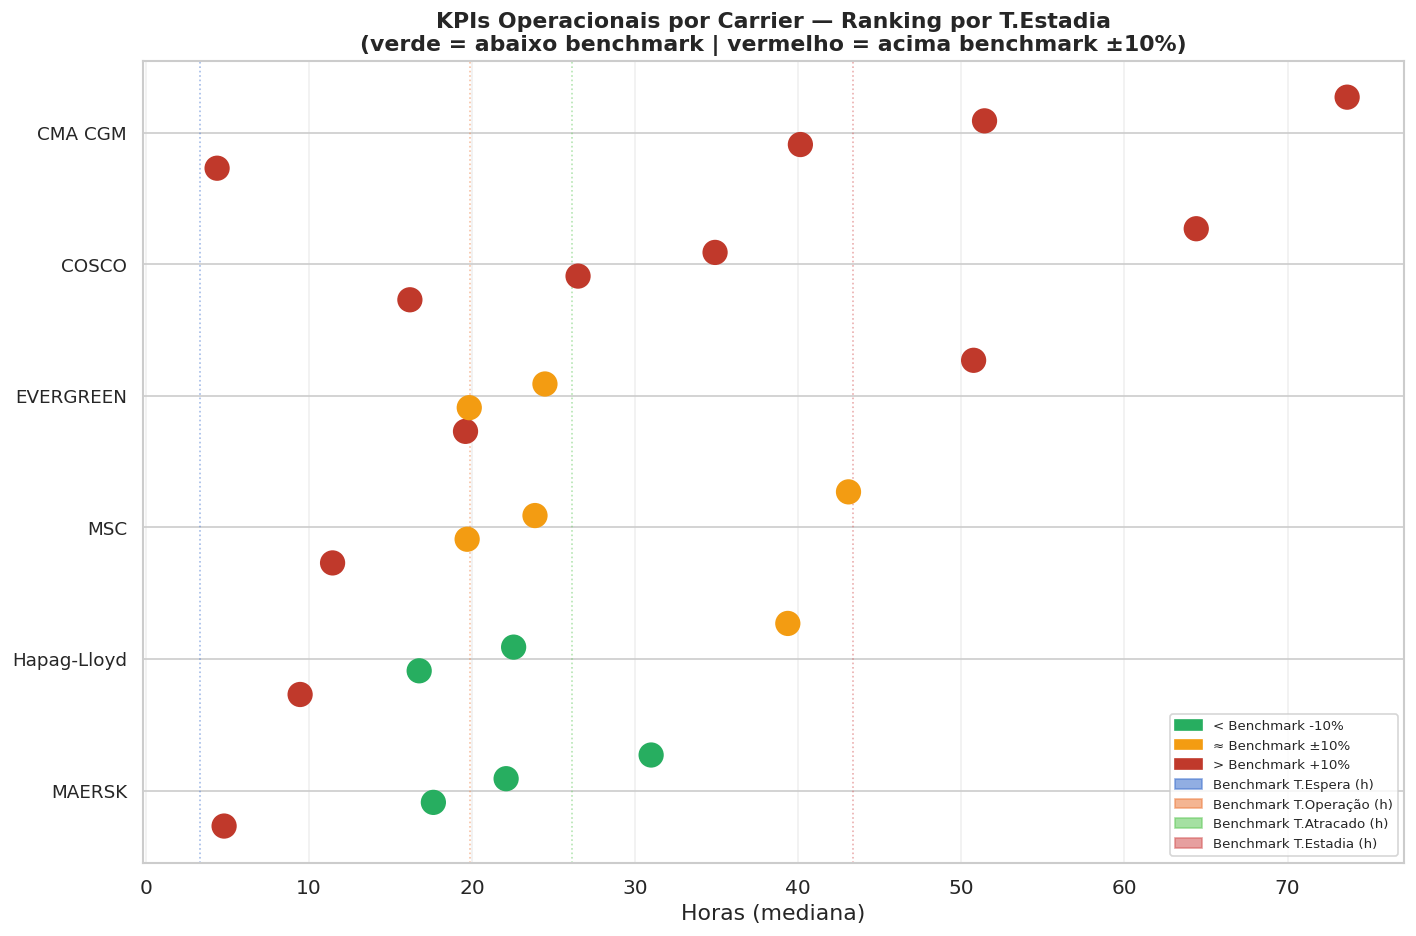


Ranking KPIs (melhor → pior por TEstadia):
               T.Espera (h)  T.Operação (h)  T.Atracado (h)  T.Estadia (h)
SHIPPING LINE                                                             
MAERSK                 4.80           17.63           22.09          30.98
Hapag-Lloyd            9.46           16.76           22.55          39.36
MSC                   11.45           19.70           23.86          43.08
EVERGREEN             19.60           19.83           24.47          50.75
COSCO                 16.19           26.50           34.90          64.40
CMA CGM                4.37           40.13           51.42          73.65

Benchmark mercado (mediana LC+Cab):
  T.Espera (h)         3.33h
  T.Operação (h)       19.90h
  T.Atracado (h)       26.15h
  T.Estadia (h)        43.33h


In [12]:
# Ranking por TEstadia mediana
ranking_kpi = kpi_carrier[['TEsperaAtracacao','TOperacao','TAtracado','TEstadia']].copy()
ranking_kpi.columns = ['T.Espera (h)','T.Operação (h)','T.Atracado (h)','T.Estadia (h)']
ranking_kpi = ranking_kpi.sort_values('T.Estadia (h)')

# Colorir acima/abaixo do benchmark
bench_vals = {
    'T.Espera (h)'   : benchmark['TEsperaAtracacao'],
    'T.Operação (h)' : benchmark['TOperacao'],
    'T.Atracado (h)' : benchmark['TAtracado'],
    'T.Estadia (h)'  : benchmark['TEstadia'],
}

fig, ax = plt.subplots(figsize=(12, len(ranking_kpi) * 1.0 + 2))
y_pos = np.arange(len(ranking_kpi))

for i, col in enumerate(['T.Espera (h)', 'T.Operação (h)', 'T.Atracado (h)', 'T.Estadia (h)']):
    vals = ranking_kpi[col].values
    bench = bench_vals[col]
    colors_dot = ['#c0392b' if v > bench * 1.1 else '#27ae60' if v < bench * 0.9 else '#f39c12'
                  for v in vals]
    ax.scatter(vals, y_pos + i * 0.18, c=colors_dot, s=200, zorder=3, label=col if i == 0 else '')
    ax.axvline(bench, color=f'C{i}', linestyle=':', alpha=0.5, linewidth=1)

ax.set_yticks(y_pos + 0.27)
ax.set_yticklabels(ranking_kpi.index, fontsize=11)
ax.set_xlabel('Horas (mediana)')
ax.set_title('KPIs Operacionais por Carrier — Ranking por T.Estadia\n'
             '(verde = abaixo benchmark | vermelho = acima benchmark ±10%)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Legenda manual
import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color='#27ae60', label='< Benchmark -10%'),
    mpatches.Patch(color='#f39c12', label='≈ Benchmark ±10%'),
    mpatches.Patch(color='#c0392b', label='> Benchmark +10%'),
]
for j, col in enumerate(['T.Espera (h)', 'T.Operação (h)', 'T.Atracado (h)', 'T.Estadia (h)']):
    patches.append(mpatches.Patch(color=f'C{j}', alpha=0.6, label=f'Benchmark {col}'))
ax.legend(handles=patches, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(OUT / 'nb10_05_ranking_kpis.png', bbox_inches='tight')
plt.show()

print('\nRanking KPIs (melhor → pior por TEstadia):')
print(ranking_kpi.to_string())
print('\nBenchmark mercado (mediana LC+Cab):')
for k, bv in bench_vals.items():
    print(f'  {k:<20} {bv:.2f}h')

### 3.4 Scatter: Nº Escalas × TEstadia (tamanho = nº portos)

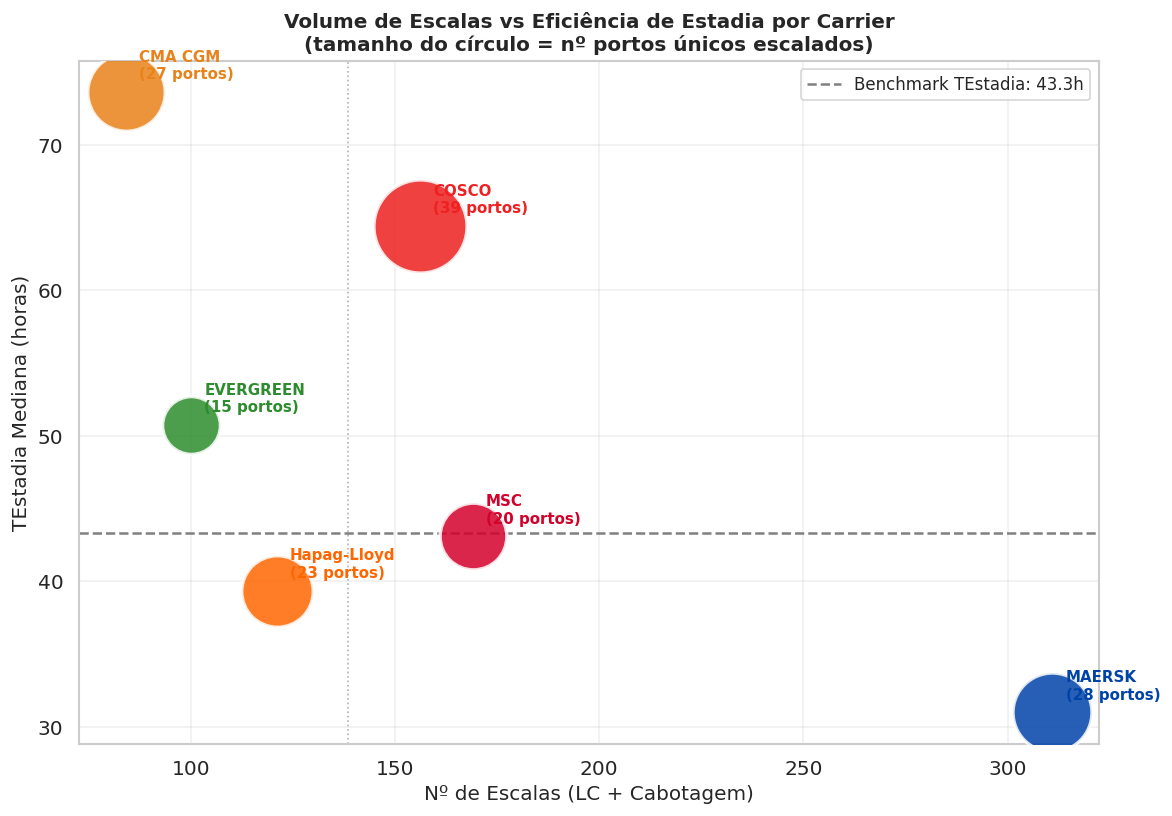

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

for carrier in kpi_carrier.index:
    if carrier not in tabela_escalas.index:
        continue
    n_esc    = tabela_escalas.loc[carrier, 'Total_Escalas']
    t_est    = kpi_carrier.loc[carrier, 'TEstadia']
    n_portos = tabela_escalas.loc[carrier, 'Portos_Unicos']
    color    = CARRIER_COLORS.get(carrier, '#888')
    size     = n_portos * 80

    ax.scatter(n_esc, t_est, s=size, color=color, alpha=0.85,
               edgecolors='white', linewidth=2, zorder=3)
    ax.annotate(f'{carrier}\n({n_portos} portos)',
                xy=(n_esc, t_est), xytext=(8, 8),
                textcoords='offset points',
                fontsize=9, fontweight='bold', color=color)

ax.axhline(benchmark['TEstadia'], color='gray', linestyle='--', linewidth=1.5,
           label=f'Benchmark TEstadia: {benchmark["TEstadia"]:.1f}h')
ax.set_xlabel('Nº de Escalas (LC + Cabotagem)', fontsize=12)
ax.set_ylabel('TEstadia Mediana (horas)', fontsize=12)
ax.set_title('Volume de Escalas vs Eficiência de Estadia por Carrier\n'
             '(tamanho do círculo = nº portos únicos escalados)', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Quadrantes
med_esc = tabela_escalas.loc[kpi_carrier.index, 'Total_Escalas'].median()
ax.axvline(med_esc, color='gray', linestyle=':', linewidth=1, alpha=0.6)

plt.tight_layout()
plt.savefig(OUT / 'nb10_06_scatter_escalas_estadia.png', bbox_inches='tight')
plt.show()

## 4. Análise Parte 3 — Padrão de Deployment

### 4.1 Heatmap: Carrier × Porto (Top 20 portos)

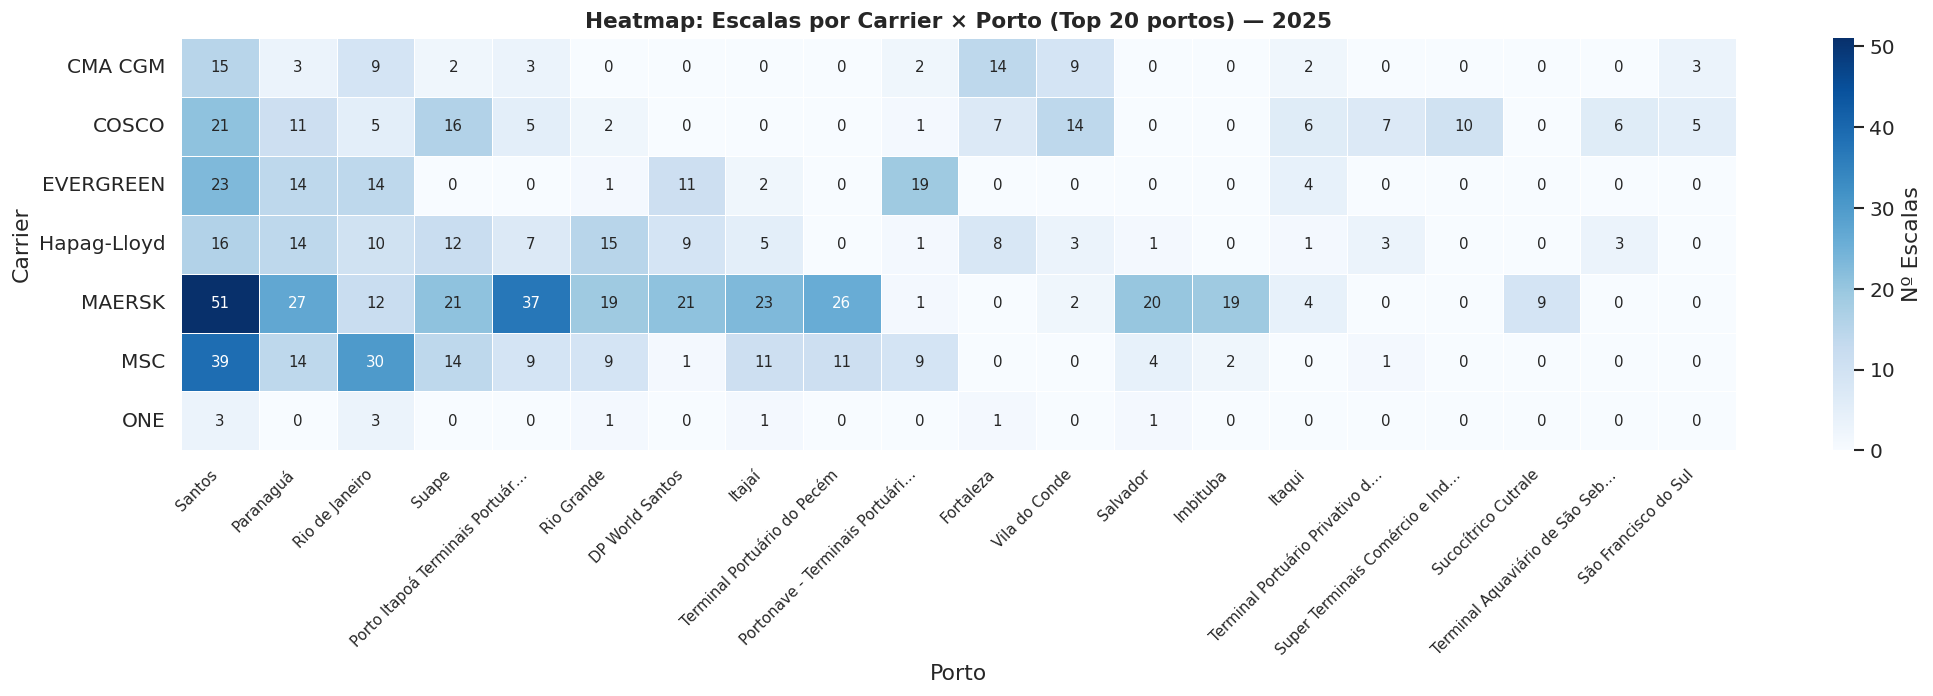

In [14]:
# Top 20 portos por total de escalas identificadas
top_portos_20 = (
    carriers['Porto Atracação']
    .value_counts()
    .head(20)
    .index
    .tolist()
)

heat = (
    carriers[carriers['Porto Atracação'].isin(top_portos_20)]
    .groupby(['SHIPPING LINE', 'Porto Atracação'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top_portos_20, fill_value=0)
)

# Abreviar nomes de porto
def abrev_porto(s, n=30):
    return s[:n] + '…' if len(s) > n else s

heat.columns = [abrev_porto(c) for c in heat.columns]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(heat, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Nº Escalas'},
            annot_kws={'size': 9})
ax.set_title('Heatmap: Escalas por Carrier × Porto (Top 20 portos) — 2025',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Porto')
ax.set_ylabel('Carrier')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'nb10_07_heatmap_carrier_porto.png', bbox_inches='tight')
plt.show()

### 4.2 Concentração vs Diversificação de Deployment

Concentração de Deployment por Carrier (HHI: maior = mais concentrado):
               Total_Portos  Portos_GE5_esc                             Top1_porto  Top1_pct  Top3_pct     HHI
SHIPPING LINE                                                                                                 
ZIM                       2               0  Terminal Marítimo de Ponta da Madeira      50.0     100.0  5000.0
EVERGREEN                15               5                                 Santos      23.0      56.0  1448.0
ONE                       9               0                                 Santos      20.0      53.3  1378.0
MSC                      20               9                                 Santos      23.1      49.1  1176.0
CMA CGM                  27               4                                 Santos      17.9      45.2   935.0
MAERSK                   28              12                                 Santos      16.4      37.0   846.0
Hapag-Lloyd              23             

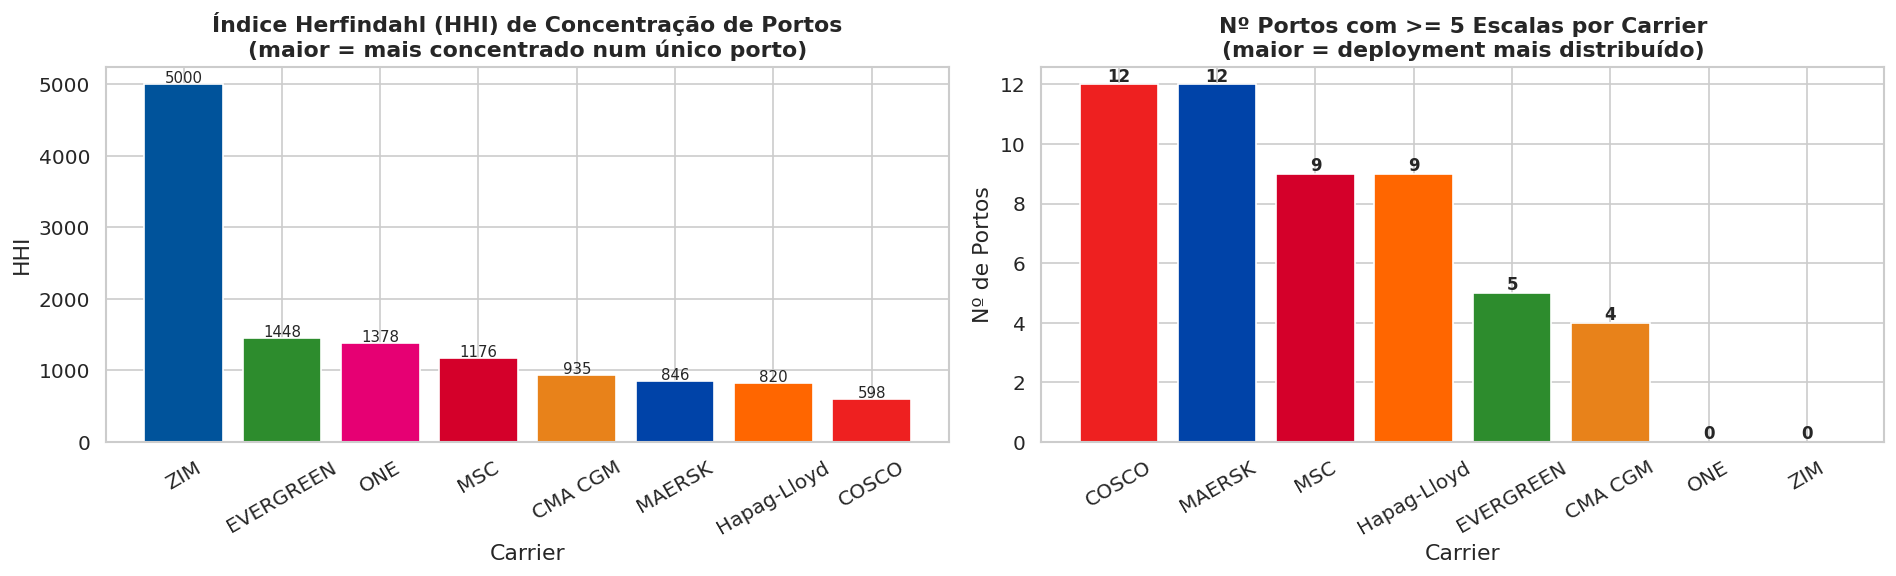

In [15]:
# Concentração de deployment: computação via pandas pura
porto_counts_all = (
    carriers.groupby(["SHIPPING LINE", "Porto Atracação"])
    .size()
    .reset_index(name="n_esc")
)

conc_rows = []
for c_name in carriers["SHIPPING LINE"].unique():
    c_pc = porto_counts_all[porto_counts_all["SHIPPING LINE"] == c_name]
    total = int(c_pc["n_esc"].sum())
    n_portos_tot = int(c_pc["Porto Atracação"].nunique())
    n_portos_ge5 = int((c_pc["n_esc"] >= 5).sum())
    top1_porto = c_pc.sort_values("n_esc", ascending=False).iloc[0]["Porto Atracação"]
    top1_pct   = round(float(c_pc.sort_values("n_esc", ascending=False).iloc[0]["n_esc"]) / total * 100, 1)
    top3_pct   = round(float(c_pc.sort_values("n_esc", ascending=False)["n_esc"].head(3).sum()) / total * 100, 1)
    hhi_val    = round(float(((c_pc["n_esc"] / total) ** 2).sum() * 10000), 0)
    conc_rows.append({
        "SHIPPING LINE": c_name, "Total_Portos": n_portos_tot,
        "Portos_GE5_esc": n_portos_ge5, "Top1_porto": top1_porto,
        "Top1_pct": top1_pct, "Top3_pct": top3_pct, "HHI": hhi_val
    })

conc_df = pd.DataFrame(conc_rows).set_index("SHIPPING LINE").sort_values("HHI", ascending=False)

print("Concentração de Deployment por Carrier (HHI: maior = mais concentrado):")
print(conc_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hhi_sorted = conc_df["HHI"].sort_values(ascending=False)
colors_hhi = [CARRIER_COLORS.get(c, "#888") for c in hhi_sorted.index]
axes[0].bar(hhi_sorted.index, hhi_sorted.values.astype(float), color=colors_hhi, edgecolor="white")
axes[0].set_title("Índice Herfindahl (HHI) de Concentração de Portos\n(maior = mais concentrado num único porto)", fontweight="bold")
axes[0].set_xlabel("Carrier")
axes[0].set_ylabel("HHI")
axes[0].tick_params(axis="x", rotation=30)
for xi, hhi_v in enumerate(hhi_sorted.values.astype(float)):
    axes[0].text(xi, hhi_v + 20, f"{int(hhi_v)}", ha="center", fontsize=9)

p5_sorted = conc_df["Portos_GE5_esc"].sort_values(ascending=False)
colors_p5 = [CARRIER_COLORS.get(c, "#888") for c in p5_sorted.index]
axes[1].bar(p5_sorted.index, p5_sorted.values.astype(int), color=colors_p5, edgecolor="white")
axes[1].set_title("Nº Portos com >= 5 Escalas por Carrier\n(maior = deployment mais distribuído)", fontweight="bold")
axes[1].set_xlabel("Carrier")
axes[1].set_ylabel("Nº de Portos")
axes[1].tick_params(axis="x", rotation=30)
for xi, p5_v in enumerate(p5_sorted.values.astype(int)):
    axes[1].text(xi, p5_v + 0.1, str(p5_v), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(OUT / "nb10_08_concentracao_deployment.png", bbox_inches="tight")
plt.show()


### 4.3 ULCV e Sub-Panamax: Onde Operam?

In [16]:
# ULCV (Ultra Large > 18k TEU)
ulcv = carriers[carriers['vessel_segment'] == 'Ultra Large (> 18k TEU)']
print('ULCV — Escalas por Carrier e Porto:')
if len(ulcv) > 0:
    ulcv_tab = ulcv.groupby(['SHIPPING LINE', 'Porto Atracação']).size().reset_index(name='Escalas')
    ulcv_tab = ulcv_tab.sort_values(['SHIPPING LINE', 'Escalas'], ascending=[True, False])
    print(ulcv_tab.to_string(index=False))
else:
    print('  Nenhuma escala ULCV identificada')

print()

# Sub-Panamax fora dos grandes portos
grandes_portos = ['Santos', 'Rio de Janeiro', 'Paranaguá', 'Itajaí', 'Suape']
sub = carriers[
    carriers['vessel_segment'].str.contains('Sub-Panamax', na=False)
]
sub_secundario = sub[~sub['Porto Atracação'].isin(grandes_portos)]

print('Sub-Panamax em portos secundários (excl. Santos/RJ/Paranaguá/Itajaí/Suape):')
if len(sub_secundario) > 0:
    print(sub_secundario.groupby(['SHIPPING LINE', 'Porto Atracação'])
          .size().sort_values(ascending=False).head(20).to_string())
else:
    print('  Nenhuma escala')

# New Panamax por carrier (grandes rotas)
np_ships = carriers[carriers['vessel_segment'] == 'New Panamax (12k-18k TEU)']
print('\nNew Panamax por carrier e porto (top 15):')
print(np_ships.groupby(['SHIPPING LINE', 'Porto Atracação'])
      .size().sort_values(ascending=False).head(15).to_string())

ULCV — Escalas por Carrier e Porto:
SHIPPING LINE                                              Porto Atracação  Escalas
    EVERGREEN                                  Terminal Marítimo Ponta Ubu        2
    EVERGREEN                                                       Itaqui        1
    EVERGREEN                                                       Santos        1
    EVERGREEN Terminal Integrador Portuário Luiz Antonio Mesquita - TIPLAM        1
  Hapag-Lloyd                           Porto do Açu - Terminal de Minério        1
          MSC                                               Rio de Janeiro        2
          MSC                                                       Santos        2
          MSC                                                    Paranaguá        1
          MSC                            Porto Itapoá Terminais Portuários        1
          MSC                                                   Rio Grande        1

Sub-Panamax em portos secundários (excl

## 5. Análise Parte 4 — Frota Registada vs Activa

In [17]:
frota_activa = (
    carriers.groupby("SHIPPING LINE")["IMO_clean"]
    .nunique()
    .rename("Navios_Atracaram_BR")
)

tabela_frota = frota_reg.to_frame().join(frota_activa)
tabela_frota["Navios_Atracaram_BR"] = tabela_frota["Navios_Atracaram_BR"].fillna(0).astype(int)
tabela_frota["Frota_Inactiva_BR"]   = tabela_frota["Frota_Registada"] - tabela_frota["Navios_Atracaram_BR"]
tabela_frota["Pct_Activa_%"]        = (
    tabela_frota["Navios_Atracaram_BR"] / tabela_frota["Frota_Registada"] * 100
).round(1)
tabela_frota = tabela_frota.sort_values("Frota_Registada", ascending=False)

print("=== Frota Registada vs Activa no Brasil 2025 ===")
print(tabela_frota.to_string())

# Navios sem escala via pandas merge
imos_atracaram_df = (
    carriers[["SHIPPING LINE", "IMO_clean"]]
    .dropna(subset=["IMO_clean"])
    .drop_duplicates()
    .rename(columns={"IMO_clean": "IMO_str"})
)
imos_atracaram_df["atracou"] = True
frota_status = v[["SHIPPING LINE", "IMO_str"]].copy()
frota_status["IMO_str"] = frota_status["IMO_str"].astype(str)
frota_status = frota_status.merge(imos_atracaram_df, on=["SHIPPING LINE","IMO_str"], how="left")
frota_status["atracou"] = frota_status["atracou"].fillna(False)

inativos_df = (
    frota_status[~frota_status["atracou"]]
    .groupby("SHIPPING LINE")
    .size()
    .rename("Inativos_BR")
)
print("\n--- Navios SEM atracação no Brasil em 2025 ---")
print(inativos_df.sort_values(ascending=False).to_string())


=== Frota Registada vs Activa no Brasil 2025 ===
               Frota_Registada  Navios_Atracaram_BR  Frota_Inactiva_BR  Pct_Activa_%
SHIPPING LINE                                                                       
COSCO                      335                   25                310           7.5
MAERSK                     261                   21                240           8.0
CMA CGM                    231                   13                218           5.6
MSC                        220                   19                201           8.6
EVERGREEN                  142                   17                125          12.0
Hapag-Lloyd                100                    6                 94           6.0
ONE                         58                    1                 57           1.7
ZIM                         31                    1                 30           3.2

--- Navios SEM atracação no Brasil em 2025 ---
SHIPPING LINE
COSCO          310
MAERSK         240
C

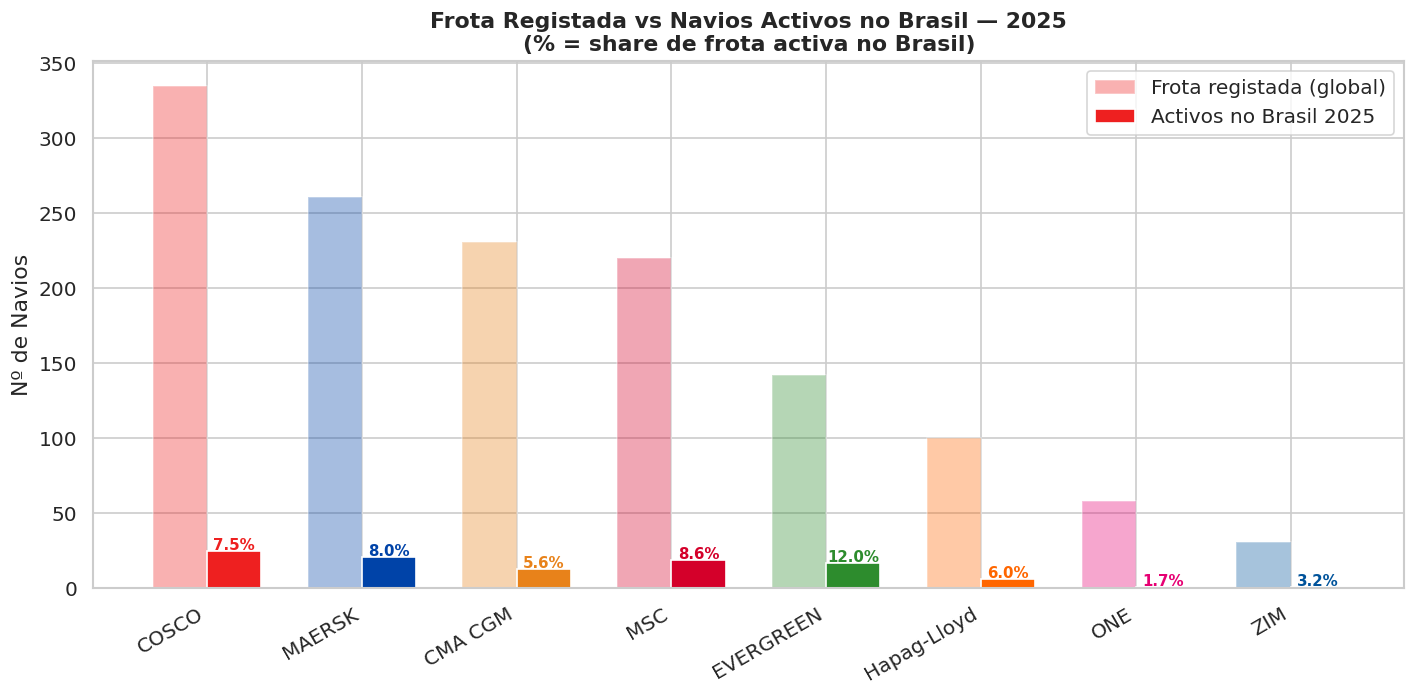


Nota: frota_activa = escalou no Brasil em 2025.
Navios sem escala podem estar em rotas Ásia–Europa, transatlântico ou outras, não em desarmamento.


In [18]:
# Visualização frota activa
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(tabela_frota))
w = 0.35

colors_reg = [CARRIER_COLORS.get(c, '#888') for c in tabela_frota.index]
bars_reg = ax.bar(x - w/2, tabela_frota['Frota_Registada'], width=w,
                  label='Frota registada (global)', 
                  color=colors_reg, alpha=0.35, edgecolor='white')
bars_act = ax.bar(x + w/2, tabela_frota['Navios_Atracaram_BR'], width=w,
                  label='Activos no Brasil 2025',
                  color=colors_reg, alpha=1.0, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(tabela_frota.index, rotation=30, ha='right')
ax.set_title('Frota Registada vs Navios Activos no Brasil — 2025\n'
             '(% = share de frota activa no Brasil)', fontweight='bold')
ax.set_ylabel('Nº de Navios')
ax.legend()

for xi, (carrier, row) in zip(x, tabela_frota.iterrows()):
    ax.text(xi + w/2, row['Navios_Atracaram_BR'] + 1,
            f"{row['Pct_Activa_%']}%",
            ha='center', fontsize=9, fontweight='bold',
            color=CARRIER_COLORS.get(carrier, '#888'))

plt.tight_layout()
plt.savefig(OUT / 'nb10_09_frota_activa.png', bbox_inches='tight')
plt.show()

print('\nNota: frota_activa = escalou no Brasil em 2025.')
print('Navios sem escala podem estar em rotas Ásia–Europa, transatlântico ou outras, não em desarmamento.')

## 6. Export CSV para Power BI

In [19]:
# Dataset completo para Power BI
pbi_cols = [
    "IDAtracacao", "CDTUP", "Porto Atracação", "Terminal", "UF", "Região Geográfica",
    "Mes", "Tipo de Navegação da Atracação", "Tipo de Operação",
    "IMO_clean", "carrier_label", "SHIPPING LINE", "vessel_segment",
    "CAPACIDADE (TEU)", "container_identified",
    "TEsperaAtracacao", "TEsperaInicioOp", "TOperacao",
    "TEsperaDesatracacao", "TAtracado", "TEstadia"
]
pbi_cols_ok = [c for c in pbi_cols if c in df.columns]
df[pbi_cols_ok].to_csv(PROC / "presenca_operacional_carrier_2025_pbi.csv", index=False, encoding="utf-8-sig")

# Tabela resumo carrier
kpi_rename = kpi_carrier[["TEsperaAtracacao","TOperacao","TEstadia"]].rename(
    columns={"TEsperaAtracacao":"T_Espera_med","TOperacao":"T_Operacao_med","TEstadia":"T_Estadia_med"}
)
frota_sel = tabela_frota[["Navios_Atracaram_BR","Frota_Inactiva_BR","Pct_Activa_%"]].copy()
resumo = tabela_escalas.copy()
for col_df in [kpi_rename, frota_sel]:
    for col in col_df.columns:
        resumo[col] = col_df[col]
resumo.to_csv(PROC / "resumo_carrier_2025.csv", encoding="utf-8-sig")

print("Exportado: presenca_operacional_carrier_2025_pbi.csv")
print("Exportado: resumo_carrier_2025.csv")
print(f"\nTabela final resumo carrier:")
print(resumo.round(1).to_string())


Exportado: presenca_operacional_carrier_2025_pbi.csv
Exportado: resumo_carrier_2025.csv

Tabela final resumo carrier:
               Total_Escalas  Longo_Curso  Cabotagem  Portos_Unicos  Navios_Unicos  Frota_Registada  Frota_Activa_%  Escalas_por_Navio  Share_LC_%  T_Espera_med  T_Operacao_med  T_Estadia_med  Navios_Atracaram_BR  Frota_Inactiva_BR  Pct_Activa_%
SHIPPING LINE                                                                                                                                                                                                                                        
MAERSK                   311          191        120             28             21              261             8.0               14.8        61.4           4.8            17.6           31.0                   21                240           8.0
MSC                      169          157         12             20             19              220             8.6                8.9        92

## 7. Limitações Metodológicas

In [20]:
n_id_final  = df['container_identified'].sum()
pct_id      = n_id_final / len(df) * 100

print('=' * 70)
print('LIMITAÇÕES METODOLÓGICAS')
print('=' * 70)
print()
print(f'1. COBERTURA')
print(f'   {pct_id:.1f}% das atracações LC+Cab têm carrier identificado.')
print(f'   {100-pct_id:.1f}% são outros tipos de navio (tankers, bulk, RoRo, etc.)')
print(f'   não cobertos pelo Vessels_Master_Enriched.')
print()
print(f'2. SCOPE DO VESSELS_MASTER')
print(f'   Base cobre exclusivamente container shipping lines.')
print(f'   Carriers como Hapag-Lloyd, COSCO, Maersk operam também outros')
print(f'   segmentos (tankers, bulk) não capturados nesta análise.')
print()
print(f'3. FROTA ACTIVA = ESCALOU NO BRASIL EM 2025')
print(f'   Navios sem escala no Brasil não estão necessariamente inactivos.')
print(f'   Podem estar em rotas Ásia–Europa, transatlântico ou outras regiões.')
print(f'   Interpretar como «penetração no mercado brasileiro», não como utilização global.')
print()
print(f'4. T.ESTADIA: FACTOR PORTO + CARRIER + OPERAÇÃO')
print(f'   TEstadia elevado pode reflectir:')
print(f'   (a) Mix de carga complexo — maior TOperacao')
print(f'   (b) Portos com menor produtividade')
print(f'   (c) Mix de vessel_segment — Feeder tem operações mais longas por TEU')
print(f'   (d) Scheduling do carrier — chegada fora da janela de berço')
print(f'   CMA CGM com maior TEstadia opera 80% Feeder Max — parte do efeito')
print(f'   é estrutural do segmento, não ineficiência do carrier.')
print('=' * 70)

LIMITAÇÕES METODOLÓGICAS

1. COBERTURA
   2.2% das atracações LC+Cab têm carrier identificado.
   97.8% são outros tipos de navio (tankers, bulk, RoRo, etc.)
   não cobertos pelo Vessels_Master_Enriched.

2. SCOPE DO VESSELS_MASTER
   Base cobre exclusivamente container shipping lines.
   Carriers como Hapag-Lloyd, COSCO, Maersk operam também outros
   segmentos (tankers, bulk) não capturados nesta análise.

3. FROTA ACTIVA = ESCALOU NO BRASIL EM 2025
   Navios sem escala no Brasil não estão necessariamente inactivos.
   Podem estar em rotas Ásia–Europa, transatlântico ou outras regiões.
   Interpretar como «penetração no mercado brasileiro», não como utilização global.

4. T.ESTADIA: FACTOR PORTO + CARRIER + OPERAÇÃO
   TEstadia elevado pode reflectir:
   (a) Mix de carga complexo — maior TOperacao
   (b) Portos com menor produtividade
   (c) Mix de vessel_segment — Feeder tem operações mais longas por TEU
   (d) Scheduling do carrier — chegada fora da janela de berço
   CMA CGM com m